In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import glob
import os

csv_files = glob.glob("**/credit_risk_dataset.csv", recursive=True)

print("Files found:", csv_files)

if len(csv_files) == 0:
    print("CSV not found.")
    print("Current folder:", os.getcwd())
else:
    df = pd.read_csv(csv_files[0])
    print("Dataset loaded successfully.")
    print("Shape:", df.shape)

Files found: ['credit_risk_dataset.csv']
Dataset loaded successfully.
Shape: (32581, 12)


In [3]:
import zipfile

with zipfile.ZipFile("credit_risk_dataset.csv.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [4]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'credit scoring model project.ipynb', 'credit_risk_dataset.csv', 'credit_risk_dataset.csv.zip', 'credit_risk_project_results.txt', 'credit_risk_random_forest_model.pkl', 'final_project_summary.txt', 'model_comparison_results.csv', 'README.md']


In [5]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

print(df.shape)

(32581, 12)


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 32581
Number of columns: 12


In [7]:
df.shape

(32581, 12)

In [8]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

loan_int_rate                 9.563856
person_emp_length             2.747000
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [13]:
duplicates = df[df.duplicated()]
print(duplicates)


       person_age  person_income person_home_ownership  person_emp_length  \
15975          23          42000                  RENT                5.0   
15989          23          90000              MORTGAGE                7.0   
15995          24          48000              MORTGAGE                4.0   
16025          24          10000                  RENT                8.0   
16028          23         100000              MORTGAGE                7.0   
...           ...            ...                   ...                ...   
32010          42          39996              MORTGAGE                2.0   
32047          36         250000                  RENT                2.0   
32172          49         120000              MORTGAGE               12.0   
32259          39          40000                   OWN                4.0   
32279          43          11340                  RENT                4.0   

             loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status 

In [14]:
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows after removal: 0
New dataset shape: (32416, 12)


In [15]:
df["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [16]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64

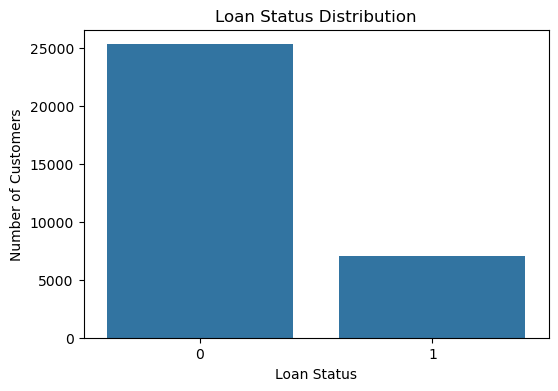

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(x="loan_status", data=df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")

plt.show()

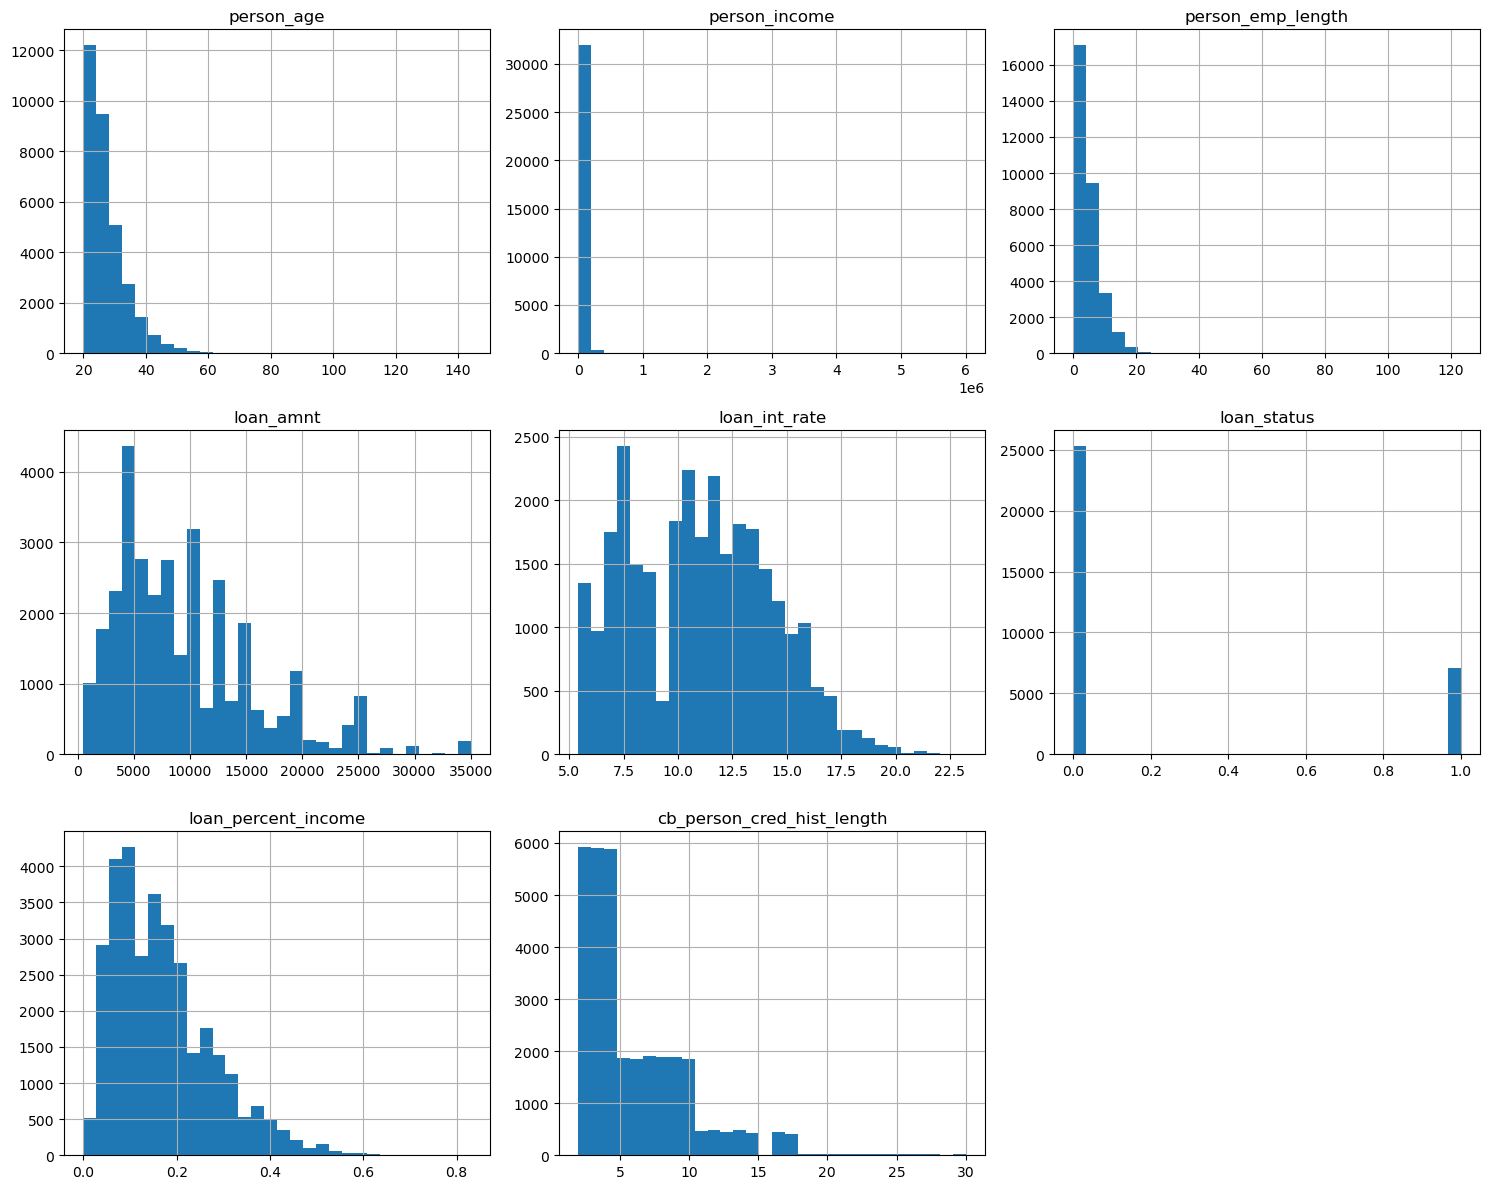

In [18]:
df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

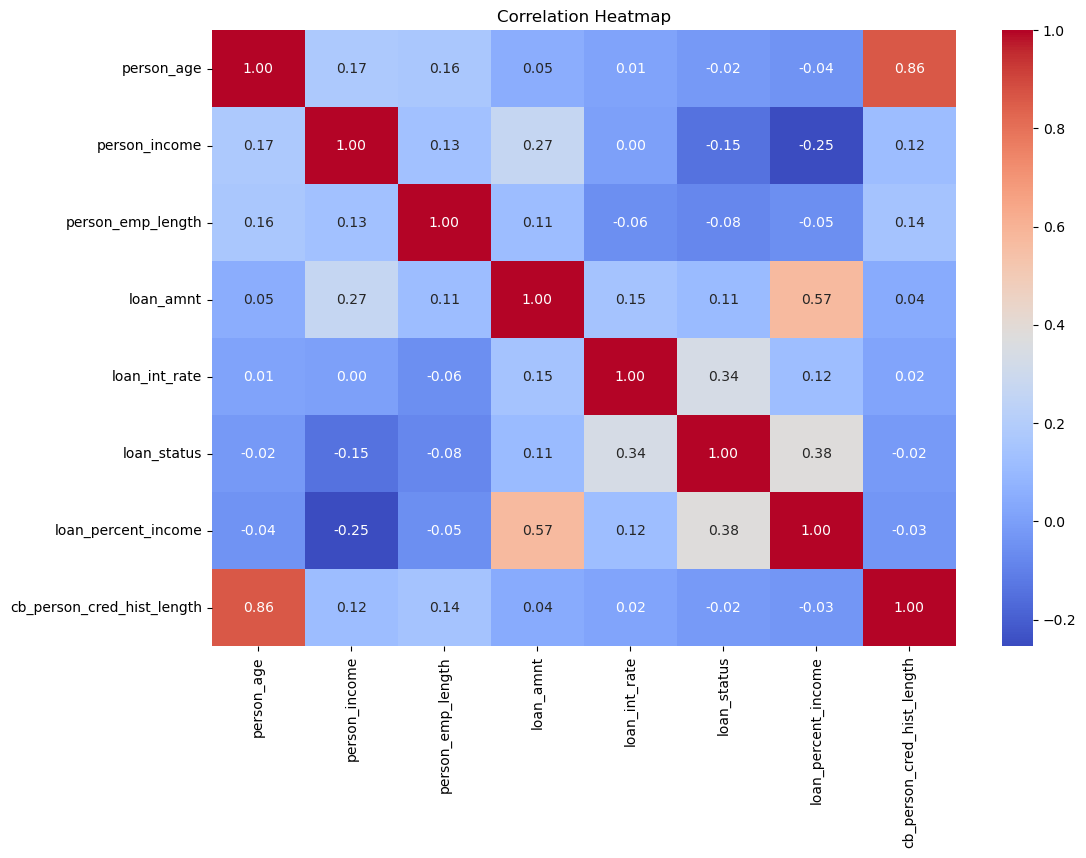

In [19]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
df = df[
    (df["person_age"] >= 18) &
    (df["person_age"] <= 100)
]

print("Shape after cleaning age:", df.shape)
print("Maximum age:", df["person_age"].max())

Shape after cleaning age: (32411, 12)
Maximum age: 94


In [21]:
df = df[
    (df["person_emp_length"].isna()) |
    (
        (df["person_emp_length"] >= 0) &
        (df["person_emp_length"] <= df["person_age"])
    )
]

print("Shape after cleaning employment length:", df.shape)
print("Missing employment length:", df["person_emp_length"].isnull().sum())

Shape after cleaning employment length: (32409, 12)
Missing employment length: 887


In [22]:
print("Current dataset shape:", df.shape)

df.describe()

Current dataset shape: (32409, 12)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,31522.000000,32409.000000,29315.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.782850,9592.486655,11.017099,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,4.037343,6320.885127,3.241718,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [23]:
df["income_loan_ratio"] = (
    df["person_income"] / (df["loan_amnt"] + 1)
)

In [24]:
df["credit_history_age_ratio"] = (
    df["cb_person_cred_hist_length"] /
    (df["person_age"] + 1)
)

In [25]:
df[[
    "income_loan_ratio",
    "credit_history_age_ratio"
]].head()

,income_loan_ratio,credit_history_age_ratio
1,9.590410,0.090909
2,1.745137,0.115385
3,1.871375,0.083333
4,1.554241,0.160000
5,3.958417,0.090909


In [26]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32409, 13)
y shape: (32409,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25927, 13)
Testing data: (6482, 13)


In [28]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'income_loan_ratio', 'credit_history_age_ratio']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [29]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [30]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [32]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [33]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [34]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully.")

Predictions completed successfully.


In [35]:
y_pred_lr

array([0, 0, 1, ..., 0, 0, 0], shape=(6482,))

In [36]:
y_prob_lr

array([0.34421847, 0.26110118, 0.65292402, ..., 0.01747129, 0.31023616,
       0.33145352], shape=(6482,))

In [37]:
print("LOGISTIC REGRESSION")
print("-------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

LOGISTIC REGRESSION
-------------------------
Accuracy: 0.8093181116939216
Precision: 0.5447834645669292
Recall: 0.7806770098730607
F1 Score: 0.6417391304347826
ROC-AUC: 0.8720749581659414


In [38]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5064
           1       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.74      0.80      0.76      6482
weighted avg       0.85      0.81      0.82      6482



In [39]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Decision Tree model created successfully.")

Decision Tree model created successfully.


In [40]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [41]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions completed successfully.")

Decision Tree predictions completed successfully.


In [42]:
print("DECISION TREE")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_dt)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_dt)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_dt)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_dt)
)

DECISION TREE
-------------------------
Accuracy: 0.9156124652884912
Precision: 0.8578471651602301
Recall: 0.7362482369534555
F1 Score: 0.7924098671726755
ROC-AUC: 0.9050651658767772


In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [44]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed successfully.")

Random Forest predictions completed successfully.


In [45]:
print("RANDOM FOREST")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

RANDOM FOREST
-------------------------
Accuracy: 0.9097500771366862
Precision: 0.8181818181818182
Recall: 0.7552891396332864
F1 Score: 0.7854785478547854
ROC-AUC: 0.9290109169624574


In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8093,0.5448,0.7807,0.6417,0.8721
1,Decision Tree,0.9156,0.8578,0.7362,0.7924,0.9051
2,Random Forest,0.9098,0.8182,0.7553,0.7855,0.9290


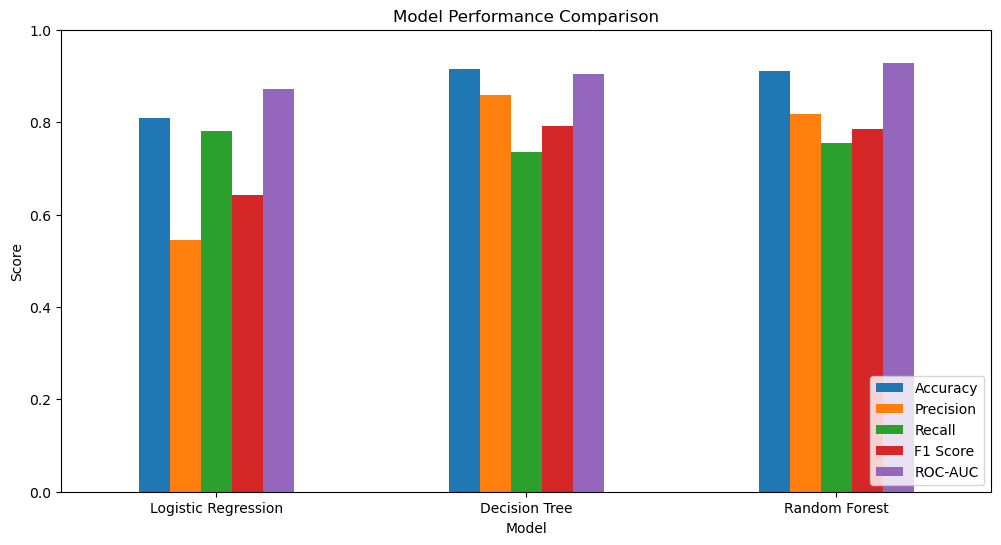

In [47]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

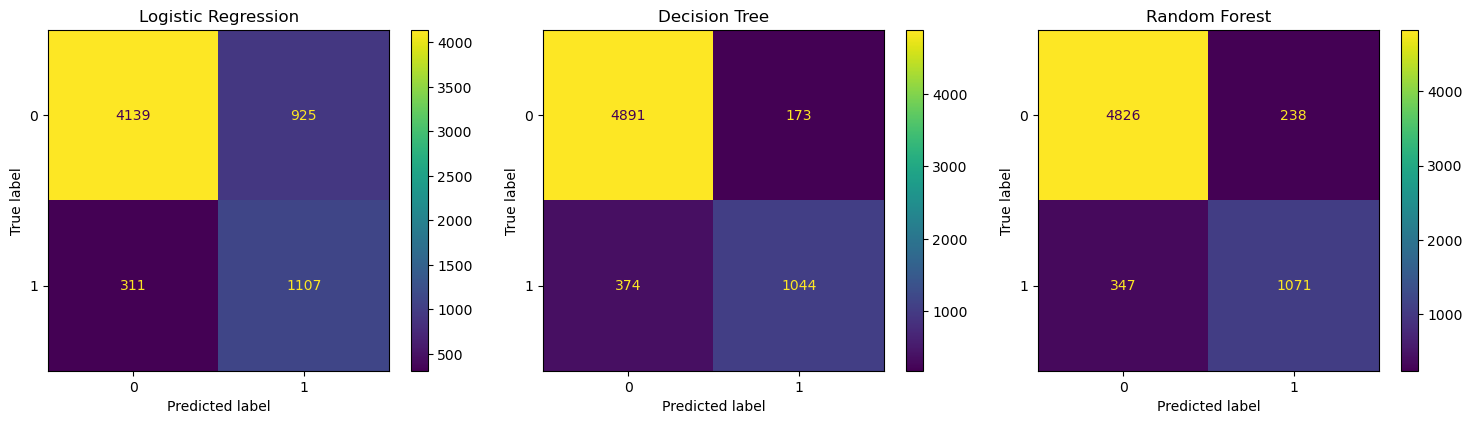

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, ax=axes[1]
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[2]
)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

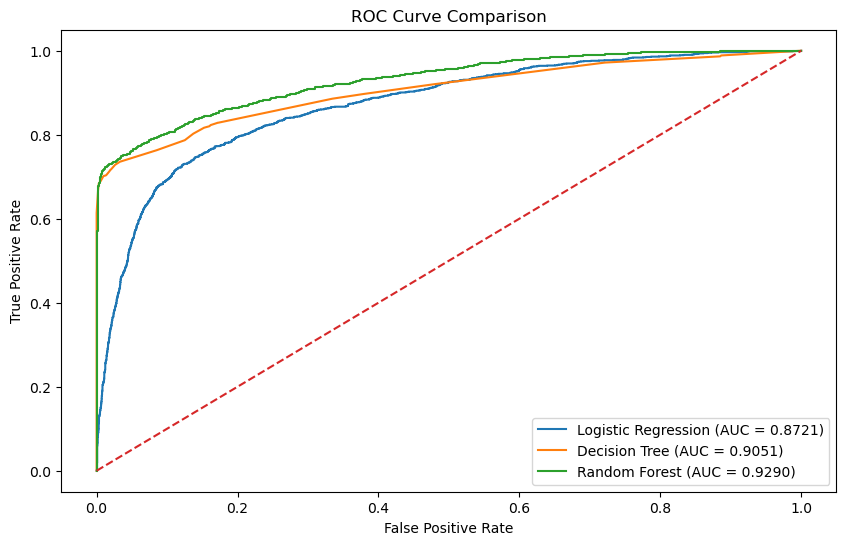

In [49]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

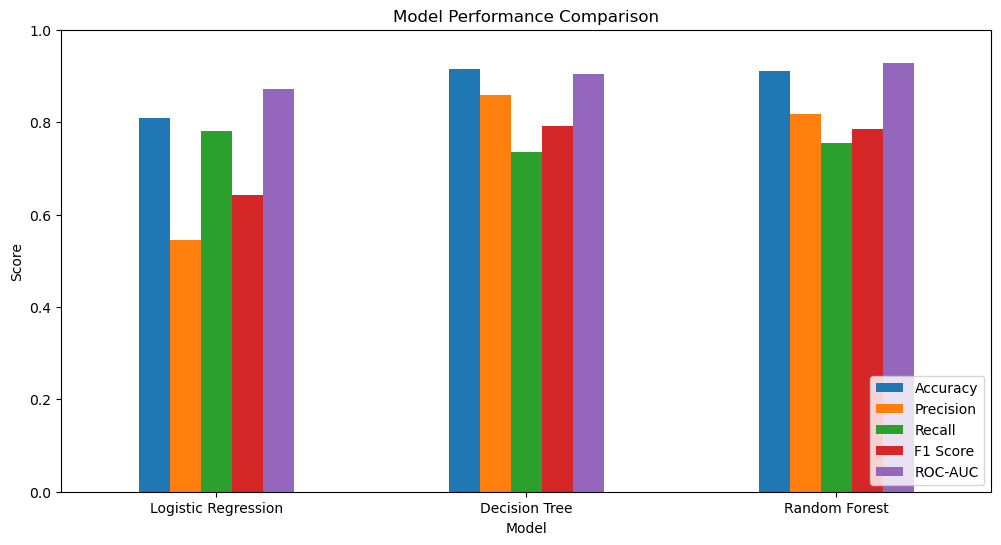

In [50]:
import matplotlib.pyplot as plt

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

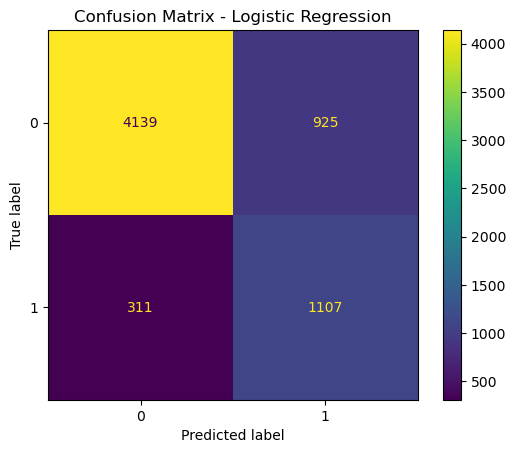

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

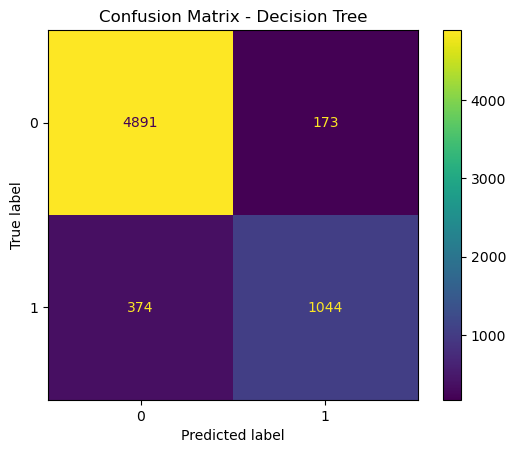

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

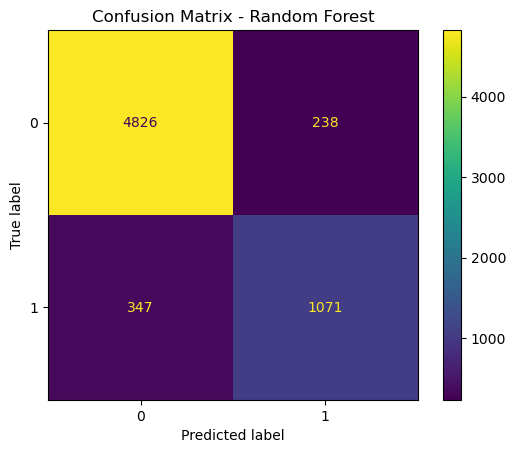

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

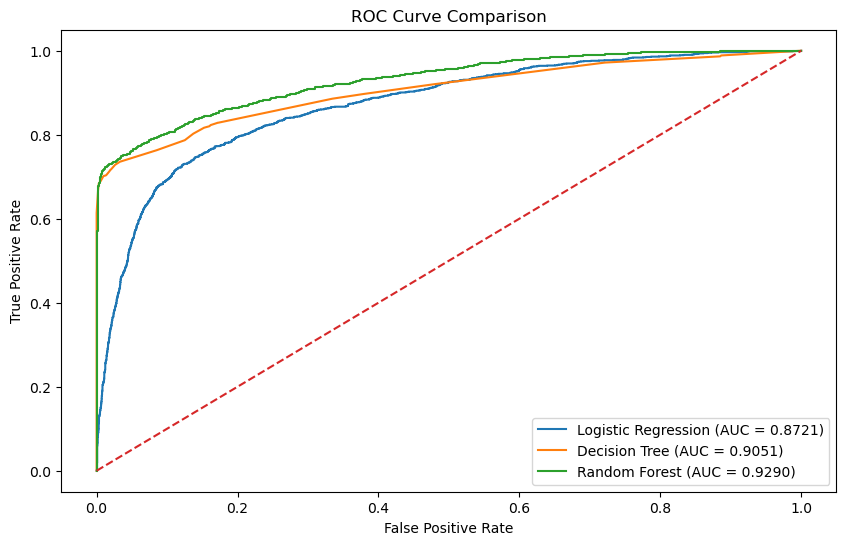

In [54]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [55]:
roc_auc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_lr),
    "Decision Tree": roc_auc_score(y_test, y_prob_dt),
    "Random Forest": roc_auc_score(y_test, y_prob_rf)
}

print("ROC-AUC Scores:")
for model, score in roc_auc_scores.items():
    print(f"{model}: {score:.4f}")

selected_model_name = max(
    roc_auc_scores,
    key=roc_auc_scores.get
)

print("\nSelected model based on ROC-AUC:", selected_model_name)

ROC-AUC Scores:
Logistic Regression: 0.8721
Decision Tree: 0.9051
Random Forest: 0.9290

Selected model based on ROC-AUC: Random Forest


In [56]:
selected_model = random_forest_model

print("Selected model stored successfully.")

Selected model stored successfully.


In [57]:
new_customer = pd.DataFrame({
    "person_age": [30],
    "person_income": [50000],
    "person_home_ownership": ["RENT"],
    "person_emp_length": [5],
    "loan_intent": ["PERSONAL"],
    "loan_grade": ["B"],
    "loan_amnt": [10000],
    "loan_int_rate": [11.5],
    "loan_percent_income": [0.20],
    "cb_person_default_on_file": ["N"],
    "cb_person_cred_hist_length": [8],
    "income_loan_ratio": [50000 / (10000 + 1)],
    "credit_history_age_ratio": [8 / (30 + 1)]
})

new_customer

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_loan_ratio,credit_history_age_ratio
0,30,50000,RENT,5,PERSONAL,B,10000,11.5,0.2,N,8,4.9995,0.258065


In [58]:
prediction = selected_model.predict(new_customer)
probability = selected_model.predict_proba(new_customer)[:, 1]

print("Prediction:", prediction[0])
print("Default Probability:", probability[0])

Prediction: 0
Default Probability: 0.24239114200807585


In [59]:
if prediction[0] == 1:
    print("Result: High Credit Risk / Likely Default")
else:
    print("Result: Lower Credit Risk / Likely No Default")

print(f"Probability of Default: {probability[0] * 100:.2f}%")

Result: Lower Credit Risk / Likely No Default
Probability of Default: 24.24%


In [60]:
print("========================================")
print("       CREDIT RISK MODEL SUMMARY")
print("========================================")

print("\nLogistic Regression ROC-AUC:",
      f"{roc_auc_score(y_test, y_prob_lr):.4f}")

print("Decision Tree ROC-AUC:",
      f"{roc_auc_score(y_test, y_prob_dt):.4f}")

print("Random Forest ROC-AUC:",
      f"{roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nSelected Model:", selected_model_name)

print("\nNew Customer Prediction:", prediction[0])

print("Default Probability:",
      f"{probability[0] * 100:.2f}%")

print("========================================")

       CREDIT RISK MODEL SUMMARY

Logistic Regression ROC-AUC: 0.8721
Decision Tree ROC-AUC: 0.9051
Random Forest ROC-AUC: 0.9290

Selected Model: Random Forest

New Customer Prediction: 0
Default Probability: 24.24%


In [61]:
results.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


In [62]:
import joblib

joblib.dump(random_forest_model, "credit_risk_random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [63]:
import os

print("Saved files:")

for file in [
    "model_comparison_results.csv",
    "credit_risk_random_forest_model.pkl"
]:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

Saved files:
✓ model_comparison_results.csv
✓ credit_risk_random_forest_model.pkl


In [64]:
print("==============================================")
print("        CREDIT RISK PREDICTION PROJECT")
print("==============================================")

print("\nDataset Information")
print("------------------------------")
print("Total records:", len(df))
print("Total features:", X.shape[1])
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nModel Performance")
print("------------------------------")
print(results.round(4).to_string(index=False))

print("\nSelected Model")
print("------------------------------")
print("Model:", selected_model_name)

print("\nNew Customer Prediction")
print("------------------------------")
print("Prediction:", prediction[0])
print(f"Default Probability: {probability[0] * 100:.2f}%")

print("\n==============================================")
print("             PROJECT COMPLETED")
print("==============================================")

        CREDIT RISK PREDICTION PROJECT

Dataset Information
------------------------------
Total records: 32409
Total features: 13
Training records: 25927
Testing records: 6482

Model Performance
------------------------------
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8093     0.5448  0.7807    0.6417   0.8721
      Decision Tree    0.9156     0.8578  0.7362    0.7924   0.9051
      Random Forest    0.9098     0.8182  0.7553    0.7855   0.9290

Selected Model
------------------------------
Model: Random Forest

New Customer Prediction
------------------------------
Prediction: 0
Default Probability: 24.24%

             PROJECT COMPLETED


In [65]:
with open("credit_risk_project_results.txt", "w") as file:
    file.write("CREDIT RISK PREDICTION PROJECT\n")
    file.write("=" * 50 + "\n\n")

    file.write("DATASET INFORMATION\n")
    file.write("-" * 30 + "\n")
    file.write(f"Total records: {len(df)}\n")
    file.write(f"Total features: {X.shape[1]}\n")
    file.write(f"Training records: {len(X_train)}\n")
    file.write(f"Testing records: {len(X_test)}\n\n")

    file.write("MODEL PERFORMANCE\n")
    file.write("-" * 30 + "\n")
    file.write(results.round(4).to_string(index=False))
    file.write("\n\n")

    file.write("SELECTED MODEL\n")
    file.write("-" * 30 + "\n")
    file.write(f"Model: {selected_model_name}\n\n")

    file.write("NEW CUSTOMER PREDICTION\n")
    file.write("-" * 30 + "\n")
    file.write(f"Prediction: {prediction[0]}\n")
    file.write(f"Default Probability: {probability[0] * 100:.2f}%\n")

print("Final project results saved successfully.")

Final project results saved successfully.


In [66]:
import os

required_files = [
    "model_comparison_results.csv",
    "credit_risk_random_forest_model.pkl",
    "credit_risk_project_results.txt"
]

print("PROJECT FILE VERIFICATION")
print("=" * 40)

for file in required_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

PROJECT FILE VERIFICATION
✓ model_comparison_results.csv
✓ credit_risk_random_forest_model.pkl
✓ credit_risk_project_results.txt


In [67]:
readme_content = """
# Credit Risk Prediction Model

## Project Overview
This project predicts whether a loan applicant is likely to default on a loan.
The project was developed as part of the CodeAlpha Machine Learning Internship.

## Objective
To build a machine learning model that can classify customers into:
- 0 → Lower Credit Risk / Likely No Default
- 1 → Higher Credit Risk / Likely Default

## Dataset
Dataset: Credit Risk Dataset

Total records after preprocessing: 32,409
Number of features: 13

## Data Preprocessing
The following preprocessing steps were performed:
- Removed duplicate records
- Handled unrealistic age values
- Cleaned employment length values
- Handled missing numerical values using median imputation
- Handled missing categorical values using most-frequent imputation
- Standardized numerical features
- Applied one-hot encoding to categorical features

## Feature Engineering
Two additional features were created:
- income_loan_ratio
- credit_history_age_ratio

## Machine Learning Models
Three classification models were trained and evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

## Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8093 | 0.5448 | 0.7807 | 0.6417 | 0.8721 |
| Decision Tree | 0.9156 | 0.8578 | 0.7362 | 0.7924 | 0.9051 |
| Random Forest | 0.9098 | 0.8182 | 0.7553 | 0.7855 | 0.9290 |

## Selected Model
Random Forest was selected based on the highest ROC-AUC among the tested models.

ROC-AUC: 0.9290

## Example Prediction
For a sample new customer, the selected Random Forest model predicted:

Prediction: 0 (Likely No Default)
Estimated Default Probability: 24.24%

This prediction is a machine learning estimate and should not be treated as an actual financial decision.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- Anaconda

## Project Files
- credit_risk_dataset.csv
- credit_risk_random_forest_model.pkl
- model_comparison_results.csv
- credit_risk_project_results.txt
- Jupyter Notebook

## Conclusion
The project successfully developed a credit risk classification system using
machine learning. Multiple models were compared using standard classification
metrics, and Random Forest achieved the highest ROC-AUC among the tested models.
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully.")

README.md created successfully.


In [68]:
import os

if os.path.exists("README.md"):
    print("✓ README.md created successfully")
    print("File size:", os.path.getsize("README.md"), "bytes")
else:
    print("✗ README.md not found")

✓ README.md created successfully
File size: 2439 bytes


In [69]:
import os

project_files = [
    "credit_risk_dataset.csv",
    "model_comparison_results.csv",
    "credit_risk_random_forest_model.pkl",
    "credit_risk_project_results.txt",
    "README.md"
]

print("==============================================")
print("       FINAL PROJECT FILE VERIFICATION")
print("==============================================")

all_found = True

for file in project_files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✓ {file}  ({size:,} bytes)")
    else:
        print(f"✗ {file}  (NOT FOUND)")
        all_found = False

print("----------------------------------------------")

if all_found:
    print("✓ ALL REQUIRED PROJECT FILES ARE READY")
else:
    print("✗ SOME FILES ARE MISSING")

print("==============================================")

       FINAL PROJECT FILE VERIFICATION
✓ credit_risk_dataset.csv  (1,804,682 bytes)
✓ model_comparison_results.csv  (386 bytes)
✓ credit_risk_random_forest_model.pkl  (4,501,867 bytes)
✓ credit_risk_project_results.txt  (733 bytes)
✓ README.md  (2,439 bytes)
----------------------------------------------
✓ ALL REQUIRED PROJECT FILES ARE READY


In [70]:
final_summary = """
CREDIT RISK PREDICTION MODEL
============================

Project: CodeAlpha Machine Learning Internship

OBJECTIVE
---------
Predict whether a loan applicant is likely to default.

DATASET
-------
Records after preprocessing: 32,409
Features used: 13
Training records: 25,927
Testing records: 6,482

MODELS TESTED
-------------
1. Logistic Regression
2. Decision Tree
3. Random Forest

MODEL PERFORMANCE
-----------------
Logistic Regression:
Accuracy  : 0.8093
Precision : 0.5448
Recall    : 0.7807
F1 Score  : 0.6417
ROC-AUC   : 0.8721

Decision Tree:
Accuracy  : 0.9156
Precision : 0.8578
Recall    : 0.7362
F1 Score  : 0.7924
ROC-AUC   : 0.9051

Random Forest:
Accuracy  : 0.9098
Precision : 0.8182
Recall    : 0.7553
F1 Score  : 0.7855
ROC-AUC   : 0.9290

SELECTED MODEL
--------------
Random Forest

Selection criterion:
Highest ROC-AUC among the tested models.

EXAMPLE PREDICTION
------------------
Prediction class: 0
Estimated default probability: 24.24%

NOTE
----
The example prediction is a machine learning estimate and is not an
actual financial or lending decision.

PROJECT STATUS
--------------
Data preprocessing       : Completed
Feature engineering      : Completed
Model training           : Completed
Model evaluation         : Completed
Model comparison         : Completed
Prediction               : Completed
Model saving             : Completed
Results saving           : Completed
README creation          : Completed

PROJECT COMPLETED
"""

with open("final_project_summary.txt", "w", encoding="utf-8") as file:
    file.write(final_summary)

print("final_project_summary.txt created successfully.")

final_project_summary.txt created successfully.


In [71]:
import os

if os.path.exists("final_project_summary.txt"):
    print("✓ final_project_summary.txt created successfully")
    print("File size:", os.path.getsize("final_project_summary.txt"), "bytes")
else:
    print("✗ final_project_summary.txt not found")

✓ final_project_summary.txt created successfully
File size: 1544 bytes
